**Import all the necessary libraries**

In [ ]:
import pandas as pd                  # For data handling
import numpy as np                   # For numerical operations

import matplotlib.pyplot as plt      # For plotting graphs
import seaborn as sns                # For advanced visualization

from sklearn.model_selection import train_test_split   # Splitting data
from sklearn.preprocessing import LabelEncoder         # Encoding categorical data

# Regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import mean_squared_error, accuracy_score,classification_report,confusion_matrix

**Loading Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML LAB/yield_df.csv")

**Data Preprocessing**

In [ ]:
print(df.head(10))
print(df.tail(10))
print(df.info())
print(df.describe())

   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   
5           5  Albania        Wheat  1990        30197   
6           6  Albania        Maize  1991        29068   
7           7  Albania     Potatoes  1991        77818   
8           8  Albania  Rice, paddy  1991        28538   
9           9  Albania      Sorghum  1991         6667   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0              121.0     16.37  
4                         1485.0         

In [ ]:
print(df.isnull().sum())
df = df.dropna()

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

**Exploratory Data Analysis (EDA)**

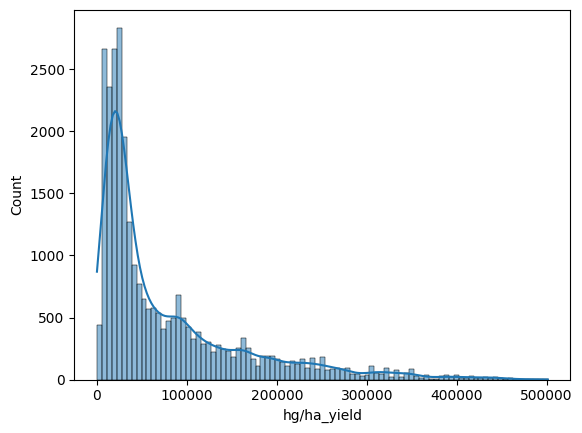

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['hg/ha_yield'], kde=True)
plt.show()

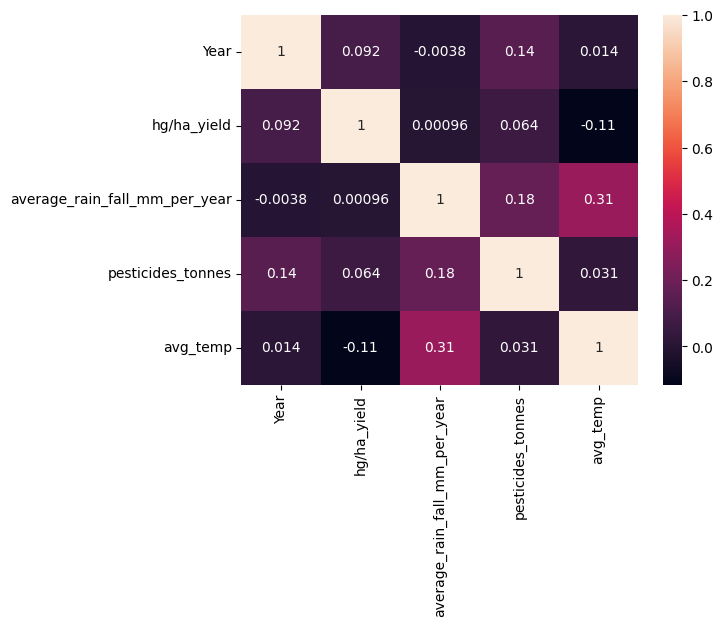

In [ ]:
corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True)
plt.show()

**Feature Engineering**

In [ ]:
df = df.rename(columns={
    'Item': 'Crop',
    'hg/ha_yield': 'Yield',
    'average_rain_fall_mm_per_year': 'Rainfall',
    'pesticides_tonnes': 'Pesticides',
    'avg_temp': 'Temperature'
})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_crop = LabelEncoder()

# Convert to lowercase
df['Area'] = df['Area'].str.lower()
df['Crop'] = df['Crop'].str.lower()

# Create encoders
le_area = LabelEncoder()
le_crop = LabelEncoder()

le_area.fit(df['Area'])
le_crop.fit(df['Crop'])

# Transform
df['Area'] = le_area.transform(df['Area'])
df['Crop'] = le_crop.transform(df['Crop'])

**Feature Selection**

In [ ]:
X = df[['Rainfall', 'Temperature', 'Pesticides', 'Area', 'Crop']]
y = df['Yield']

**Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Regression Models**

**Linear Regression**

**Random Forest Regressor**

**Model Training & Evaluation**

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor()
}
reg_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    reg_results[name] = mse
print(reg_results)

{'Linear Regression': 6687860316.681613, 'Random Forest': 198430240.87769744}


**Regression Model Comparison**

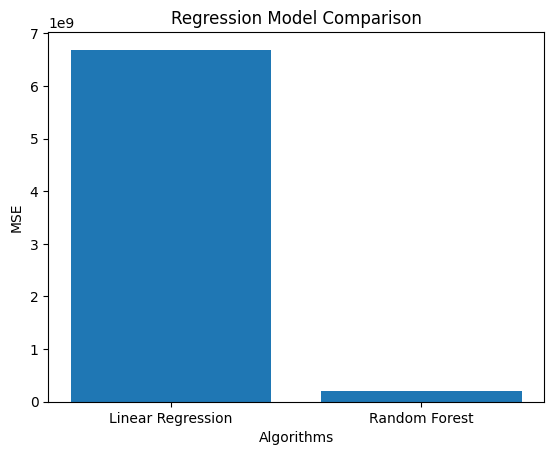

In [ ]:
import matplotlib.pyplot as plt
plt.bar(reg_results.keys(), reg_results.values())
plt.xlabel("Algorithms")
plt.ylabel("MSE")
plt.title("Regression Model Comparison")
plt.show()

**Actual vs Predicted Visualization**

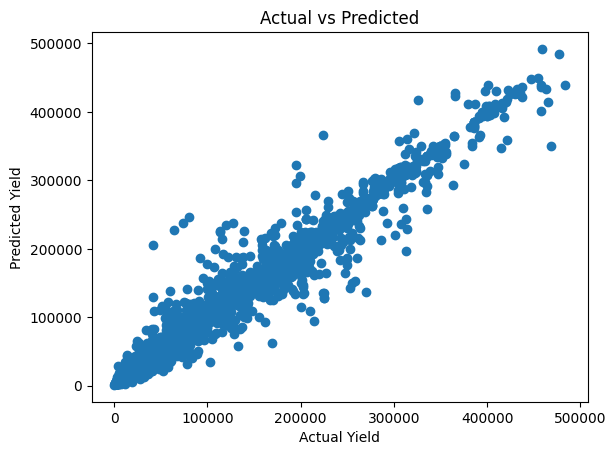

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted")
plt.show()

**Classification Models**

**Decision Tree Classifier**

**K-Nearest Neighbors (KNN)**

In [ ]:
def classify(y):
    if y < 20000:
        return 0   # Low
    elif y < 50000:
        return 1   # Medium
    else:
        return 2   # High

df['Yield_Class'] = df['Yield'].apply(classify)

In [ ]:
X = df[['Rainfall', 'Temperature', 'Pesticides', 'Area', 'Crop']]
y = df['Yield_Class']

**Model Training & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier()
}

clf_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    clf_results[name] = acc

print(clf_results)

{'Decision Tree': 0.9392812887236679, 'KNN': 0.6611789697291556}


**Confusion Matrix & Classification Report**

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Decision Tree Results:
Accuracy: 0.9394583112055231
Confusion Matrix:
 [[1346   87    4]
 [ 114 1562   62]
 [   3   72 2399]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      1437
           1       0.91      0.90      0.90      1738
           2       0.97      0.97      0.97      2474

    accuracy                           0.94      5649
   macro avg       0.93      0.94      0.93      5649
weighted avg       0.94      0.94      0.94      5649


KNN Results:
Accuracy: 0.6611789697291556
Confusion Matrix:
 [[1011  231  195]
 [ 300 1077  361]
 [ 427  400 1647]]
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.70      0.64      1437
           1       0.63      0.62      0.63      1738
           2       0.75      0.67      0.70      2474

    accuracy                           0.66      5649
   macro avg       0.65      0.66      0.66      5649
w

**Classification Comparison**

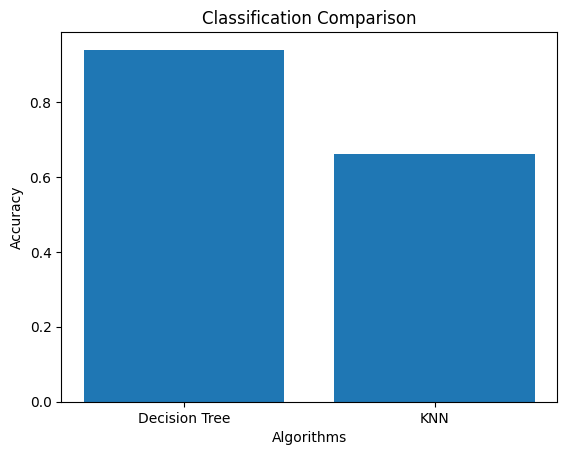

In [ ]:
import matplotlib.pyplot as plt

plt.bar(clf_results.keys(), clf_results.values())
plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Classification Comparison")
plt.show()

In [ ]:
X = df[['Rainfall', 'Temperature', 'Pesticides']]

**Clustering using K-Means**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

In [ ]:
df[['Rainfall', 'Temperature', 'Pesticides', 'Cluster']].head()

,Rainfall,Temperature,Pesticides,Cluster
0,1485.0,16.37,121.0,1
1,1485.0,16.37,121.0,1
2,1485.0,16.37,121.0,1
3,1485.0,16.37,121.0,1
4,1485.0,16.37,121.0,1


**Cluster Visualization**

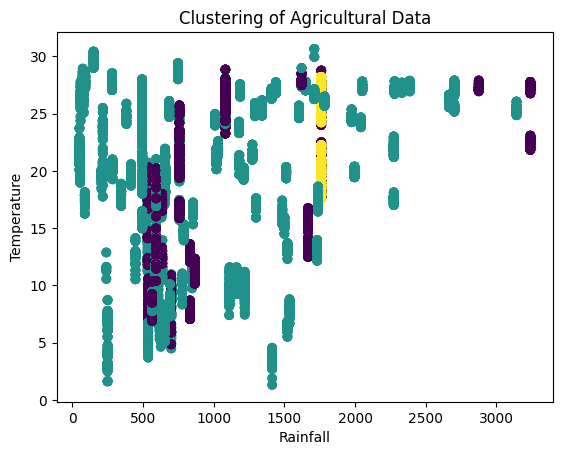

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Rainfall'], df['Temperature'], c=df['Cluster'])
plt.xlabel("Rainfall")
plt.ylabel("Temperature")
plt.title("Clustering of Agricultural Data")
plt.show()

**Clustering Evaluation**

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df['Cluster'])
print("Silhoutte_score:",score)

Silhoutte_score: 0.6584400153187758


**FINAL RESULTS**

In [ ]:
import pandas as pd

reg_df = pd.DataFrame(list(reg_results.items()), columns=["Algorithm", "MSE"])
clf_df = pd.DataFrame(list(clf_results.items()), columns=["Algorithm", "Accuracy"])

print(reg_df)
print(clf_df)

           Algorithm           MSE
0  Linear Regression  6.687860e+09
1      Random Forest  1.984302e+08
       Algorithm  Accuracy
0  Decision Tree  0.939281
1            KNN  0.661179


In [ ]:
print("\nAvailable Areas (sample):", list(le_area.classes_)[:10])
print("Available Crops (sample):", list(le_crop.classes_)[:10])
print("\nEnter details to predict crop yield:")

rainfall = float(input("Enter Rainfall: "))
temperature = float(input("Enter Temperature: "))
pesticides = float(input("Enter Pesticides: "))
area = input("Enter Area: ").strip().lower()
crop = input("Enter Crop: ").strip().lower()
if area not in le_area.classes_:
    print("❌ Invalid Area! Choose from:", list(le_area.classes_))

elif crop not in le_crop.classes_:
    print("❌ Invalid Crop! Choose from:", list(le_crop.classes_))

else:
    area_encoded = le_area.transform([area])[0]
    crop_encoded = le_crop.transform([crop])[0]

    user_data = pd.DataFrame([{
    'Rainfall': rainfall,
    'Temperature': temperature,
    'Pesticides': pesticides,
    'Area': area_encoded,
    'Crop': crop_encoded
    }])

    prediction = rf.predict(user_data)

    print("✅ Predicted Yield:", prediction[0])


Available Areas (sample): ['albania', 'algeria', 'angola', 'argentina', 'armenia', 'australia', 'austria', 'azerbaijan', 'bahamas', 'bahrain']
Available Crops (sample): ['cassava', 'maize', 'plantains and others', 'potatoes', 'rice, paddy', 'sorghum', 'soybeans', 'sweet potatoes', 'wheat', 'yams']

Enter details to predict crop yield:
Enter Rainfall: 1200
Enter Temperature: 30
Enter Pesticides: 300
Enter Area: albania
Enter Crop: cassava
✅ Predicted Yield: 82457.39


In [ ]:
labels = {
    0: "Low",
    1: "Medium",
    2: "High"
}

In [ ]:
predicted_class = classify(prediction[0])
print("Yield Category:", labels[predicted_class])

Yield Category: High
